# Multicollinearity Motivation

**Project question:** Why can individually plausible OLS coefficients become unstable when predictors move together?

By the end of this notebook, you should be able to:

- identify correlated predictor groups and high variance-inflation factors
- separate coefficient instability from overall predictive signal
- explain why shrinkage may help prediction without proving causality

This notebook is a demonstration, not a homework assignment. The data are
synthetic and were generated for teaching; numerical results should not be
interpreted as evidence about a real organization or population.

In [1]:

from lite_setup import ensure_packages
await ensure_packages()

Using the current Python environment.


In [2]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
if not DATA.exists():
    raise FileNotFoundError("Open this notebook from the JupyterLite files root so data/ is available.")

In [3]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

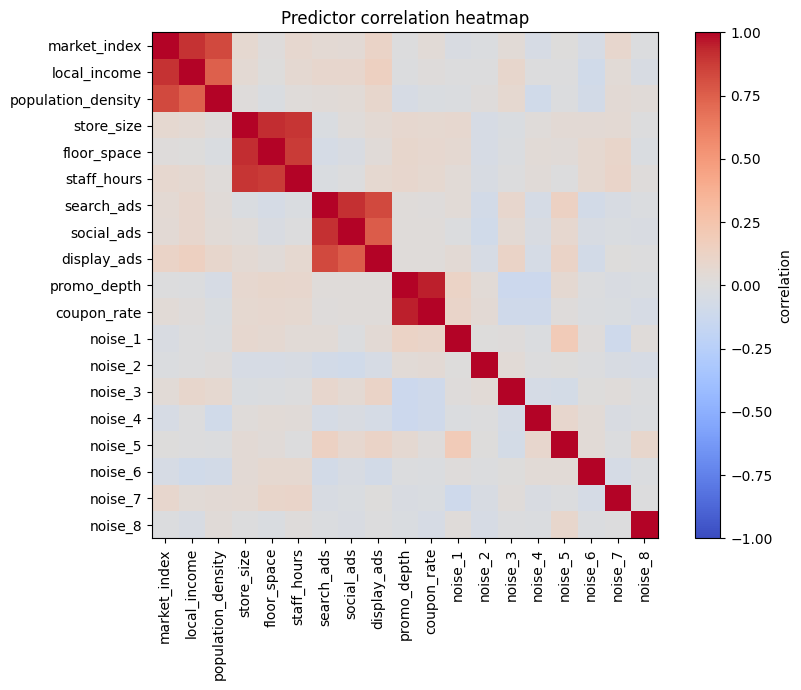

In [4]:
df = pd.read_csv(DATA / 'simulated_correlated_predictors.csv')
X = df.drop(columns=['id', 'weekly_sales'])
y = df['weekly_sales']
corr = X.corr()
plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Predictor correlation heatmap')
plt.tight_layout()

In [5]:
X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           weekly_sales   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     52.81
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           3.10e-67
Time:                        00:25:40   Log-Likelihood:                -650.03
No. Observations:                 220   AIC:                             1340.
Df Residuals:                     200   BIC:                             1408.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 50.5022      0.343    147.087      0.000      49.825      51.179
market_index           4.8149      0.922      5.221      0.000       2.996       6.633
local_income           3.5485      0.860      4.125      0.000       1.852       5.245
population_density     0.2333      0.669      0.349      0.727      -1.085       1.552
store_size             1.5300      0.963      1.589      0.114      -0.368       3.428
floor_space            1.8994      0.976      1.947      0.053      -0.025       3.823
staff_hours            1.6599      0.978      1.697      0.091      -0.269       3.588
search_ads             1.8090      0.911      1.986      0.048       0.013       3.605
social_ads             1.0679      0.903      1.182      0.238      -0.713       2.849
display_ads            0.1005      0.726      0.138      0.890      -1.331       1.532
promo_depth           -0.7974      1.034     -0.771      0.442      -2.837       1.243
coupon_rate           -1.8776      1.199     -1.566      0.119      -4.241       0.486
noise_1               -0.1855      0.333     -0.557      0.578      -0.842       0.471
noise_2               -0.4516      0.344     -1.314      0.190      -1.129       0.226
noise_3               -0.0529      0.326     -0.162      0.871      -0.695       0.590
noise_4                0.4723      0.325      1.455      0.147      -0.168       1.112
noise_5                0.0061      0.359      0.017      0.987      -0.702       0.714
noise_6               -0.3153      0.376     -0.838      0.403      -1.058       0.427
noise_7                0.2352      0.321      0.733      0.464      -0.397       0.868
noise_8                0.1542      0.330      0.467      0.641      -0.497       0.805
==============================================================================
Omnibus:                        3.804   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.149   Jarque-Bera (JB):                4.256
Skew:                           0.117   Prob(JB):                        0.119
Kurtosis:                       3.640   Cond. No.                         7.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
vif = pd.DataFrame({
    'variable': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
})
vif.query("variable != 'const'").sort_values('VIF', ascending=False).head(10)

,variable,VIF
10,promo_depth,10.426732
11,coupon_rate,10.275692
4,store_size,9.048627
7,search_ads,9.034400
1,market_index,8.427967
5,floor_space,7.831332
8,social_ads,6.583615
6,staff_hours,5.849327
2,local_income,5.826631
9,display_ads,3.463201


VIF quantifies how much the sampling variance of an OLS coefficient is inflated by linear association with the other predictors. A high VIF is not proof that a variable should be deleted; it signals that one-at-a-time coefficient interpretation may be fragile.

In [7]:
rng = np.random.default_rng(4031)
bootstrap_coefs = []
for _ in range(100):
    sample_index = rng.integers(0, len(df), len(df))
    sample = df.iloc[sample_index]
    fitted = sm.OLS(
        sample['weekly_sales'],
        sm.add_constant(sample[X.columns]),
    ).fit()
    bootstrap_coefs.append(fitted.params.drop('const'))
coef_stability = pd.DataFrame(bootstrap_coefs).std().sort_values(ascending=False).to_frame('bootstrap_sd')
coef_stability.head(10)

,bootstrap_sd
coupon_rate,1.136665
staff_hours,1.019402
promo_depth,1.013132
floor_space,0.989453
store_size,0.965698
social_ads,0.915742
market_index,0.906805
search_ads,0.829780
display_ads,0.746487
local_income,0.743448


**Interpretation:** Large bootstrap variation shows that correlated predictors can exchange credit across samples even when the combined predictive signal remains useful. Ridge addresses variance through shrinkage; it does not make the coefficients causal.